# Couverture IMGEP (`run_2000_38D`) vs baseline humaine (2000 decouvertes)

Compare la couverture de l'espace comportemental Z (38D, 6 ACTM + 32 TT) explore par
l'experience IMGEP `run_2000_38D` (adtool) a celle du dataset humain complet (30 145 presets
Dexed), en reprenant **exactement** la methodologie et les constantes de normalisation du
rapport d'audit (`CR audit dataset EN.md`, section 2 et 9).

**Point important** : le notebook `dexed_adtool_overview.ipynb` comparait deja grossierement
les deux (`coverage_metrics` sur Z brut, non normalise). Ici on va plus loin :
1. on applique aux 38 features IMGEP la **meme transformation log-scale + z-score** que celle
   utilisee pour construire l'espace Z du dataset humain (`utils.timbrefeatures.TimbreFeatures`,
   constantes figees, pas besoin de refit) -- comparaison directe, feature par feature, dans le
   meme espace normalise ;
2. on projette les deux nuages de points sur la **meme base PCA et le meme embedding UMAP**
   (fittes sur l'humain, IMGEP transforme dedans) pour les visualiser ensemble ;
3. on calcule les metriques de couverture (distance NN moyenne native 38D, occupation de
   grille) **des deux cotes avec la meme methodologie**, plus une reference uniforme aleatoire.

Caveat connu (deja note dans la memoire projet) : 4 features TT (`F0`, `InHarm`, `HarmErg`,
`OddEvenRatio`) ont un ecart structurel `ttb` vs MATLAB -- mais **les deux cotes de cette
comparaison utilisent `ttb`** (le dataset humain a ete recalcule via `raw_timbre_features_ttb.df.pickle`,
et adtool utilise aussi `ttb`), donc ce biais s'annule ici et n'affecte pas la comparaison.

## 1. Setup

In [1]:
import os, sys, pathlib, json
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA

SPINVAE2_ROOT = pathlib.Path.home() / 'projects' / 'spinvae2'
ADTOOL_ROOT = pathlib.Path.home() / 'projects' / 'adtool'
sys.path.insert(0, str(SPINVAE2_ROOT))
sys.path.insert(0, str(ADTOOL_ROOT))
sys.path.insert(0, str(ADTOOL_ROOT / 'examples' / 'dexed'))

DATASET_ROOT = pathlib.Path('/data2/anasynth_nonbp/longeot/spinvae2_datasets/Dexed')
RUN_DIR = ADTOOL_ROOT / 'examples' / 'dexed' / 'run_2000_38D'

plt.rcParams['figure.dpi'] = 100

## 2. Baseline humaine (30 145 presets)

On recharge les features brutes `ttb` et on reproduit la selection + normalisation exacte du
papier SpinVAE2 (`TimbreFeatures` + filtre de correlation `__no_high_corr__` -> 38 features).

In [2]:
from utils.timbrefeatures import TimbreFeatures, parse_timbre_features_arguments

raw_pickle = DATASET_ROOT / 'raw_timbre_features_ttb.df.pickle'
raw_df = pd.read_pickle(raw_pickle)
print('Dataset humain: ', raw_df.shape, '--', raw_df['preset_UID'].nunique(), 'presets uniques')

tf = TimbreFeatures(raw_pickle)
Z_NAMES = parse_timbre_features_arguments(['ac_*', 'tt_*', '__no_high_corr__'])
print(f'{len(Z_NAMES)} features selectionnees (papier: 38)')

human_df = tf.postproc_df.set_index('preset_UID')
Z_human_norm = human_df[Z_NAMES].values.astype(float)   # deja log-scale + z-score
Z_human_raw = tf.preproc_df.set_index('preset_UID')[Z_NAMES].values.astype(float)  # avant normalisation
print('Z_human_norm:', Z_human_norm.shape)

Dataset humain:  (30145, 97) -- 30145 presets uniques


38 features selectionnees (papier: 38)
Z_human_norm: (30145, 38)


## 3. Verifier l'alignement des noms de features (adtool vs dataset humain)

`DexedStatistics.Z_FEATURE_NAMES` (adtool) doit etre **exactement** la meme liste, dans le
meme ordre, que `Z_NAMES` ci-dessus -- c'est ce qui garantit que les deux Z vivent dans le
meme espace.

In [3]:
from maps.DexedStatistics import Z_FEATURE_NAMES

assert Z_FEATURE_NAMES == Z_NAMES, (Z_FEATURE_NAMES, Z_NAMES)
print('OK: 38 noms de features identiques et dans le meme ordre entre adtool et le dataset humain.')

OK: 38 noms de features identiques et dans le meme ordre entre adtool et le dataset humain.


## 4. Charger les decouvertes IMGEP (`run_2000_38D`)

In [4]:
from visualize_discoveries import load_discoveries

DISCOVERIES_DIR = RUN_DIR / 'discoveries'
Z_imgep_raw, order, wav_paths = load_discoveries(DISCOVERIES_DIR)
print(f'{len(Z_imgep_raw)} decouvertes chargees, Z shape = {Z_imgep_raw.shape}')
assert Z_imgep_raw.shape[1] == len(Z_NAMES)

2000 decouvertes chargees, Z shape = (2000, 38)


## 5. Appliquer aux decouvertes IMGEP la meme transformation (log-scale + z-score)

`TimbreFeatures` applique cette transformation via des **constantes figees** (`_post_distorsion_stats`,
calculees une fois pour toutes sur le dataset d'entrainement) -- pas un fit par dataset. On peut
donc l'appliquer telle quelle a n'importe quel nouveau vecteur de 38 features nommees, y compris
les sorties IMGEP, pour obtenir une comparaison directe dans le meme espace normalise.

In [5]:
import utils.timbretoolboxstats as ttstats
from utils.timbrefeatures import _post_distorsion_stats

def apply_timbrefeatures_postproc(Z_raw: np.ndarray, names: list) -> np.ndarray:
    """Reproduit TimbreFeatures.__init__'s pre-processing (inf/NaN/failed-AC-value ->
    column median) + log-scale + z-score step, for an arbitrary (N, 38) array of raw feature
    values with the given column names. Needed because a sizeable fraction of IMGEP discoveries
    have NaN tt_AmpMod/tt_DecSlope (ttb can't estimate amplitude modulation on very short/silent
    renders) -- exactly the kind of \"invalid value\" TimbreFeatures already handles for the
    human dataset via median imputation, so we reuse the same rule rather than dropping rows."""
    df = pd.DataFrame(Z_raw, columns=names).replace([np.inf, -np.inf], np.nan)
    invalid = df.isna()
    for col in names:
        if col.startswith('ac_'):
            invalid[col] = invalid[col] | (df[col] == 0.0)
    for col in names:
        mask = invalid[col]
        if mask.any():
            median_value = df.loc[~mask, col].median()
            df.loc[mask, col] = median_value
    freq_eps = 1.0
    for col in names:
        if not col.startswith('tt_'):
            continue
        if col.startswith('tt_F0_') or col.startswith('tt_SpecCent_') \
                or col.startswith('tt_SpecSpread_') or col.startswith('tt_SpecRollOff_'):
            df[col] = np.log(freq_eps + df[col])
        elif col.startswith('tt_OddEvenRatio_'):
            df[col] = np.log(1.0 + df[col])
        elif col.startswith('tt_FrameErg_') or col.startswith('tt_RMSEnv_') or col.startswith('tt_AmpMod') \
                or col.startswith('tt_HarmErg_') or col.startswith('tt_NoiseErg_') or col.startswith('tt_HarmDev_'):
            dynamic_eps = ttstats.log_scale_dynamic_eps[col.replace('tt_', '')]
            df[col] = np.log(dynamic_eps + df[col])
        elif col.startswith('tt_SpecFlat_') or col.startswith('tt_SpecKurt_') \
                or col.startswith('tt_SpecVar_') or col.startswith('tt_InHarm_'):
            dynamic_eps = ttstats.log_scale_dynamic_eps[col.replace('tt_', '')]
            df[col] = np.log(dynamic_eps + df[col])
    mean = pd.Series(_post_distorsion_stats['mean'])[names]
    std = pd.Series(_post_distorsion_stats['std'])[names]
    return ((df[names] - mean) / std).values.astype(float)

n_invalid_raw = (~np.isfinite(Z_imgep_raw)).sum()
print(f'Valeurs invalides (inf/NaN) dans Z_imgep_raw avant imputation: {n_invalid_raw} / {Z_imgep_raw.size} '
      f'({n_invalid_raw / Z_imgep_raw.size:.1%}) -- typiquement tt_AmpMod/tt_DecSlope sur des rendus tres courts/silencieux.')

Z_imgep_norm = apply_timbrefeatures_postproc(Z_imgep_raw, Z_NAMES)
print('Z_imgep_norm:', Z_imgep_norm.shape, '-- NaNs restants:', np.isnan(Z_imgep_norm).sum())

Valeurs invalides (inf/NaN) dans Z_imgep_raw avant imputation: 2751 / 76000 (3.6%) -- typiquement tt_AmpMod/tt_DecSlope sur des rendus tres courts/silencieux.
Z_imgep_norm: (2000, 38) -- NaNs restants: 0


## 6. Comparaison feature par feature

Distribution normalisee (z-score) de chaque feature, humain vs IMGEP -- si IMGEP explore une
zone plausible de l'espace des sons Dexed, ses distributions devraient globalement chevaucher
celles du dataset humain (meme si IMGEP, guide par la curiosite, peut legitimement s'etendre
au-dela sur certains axes).

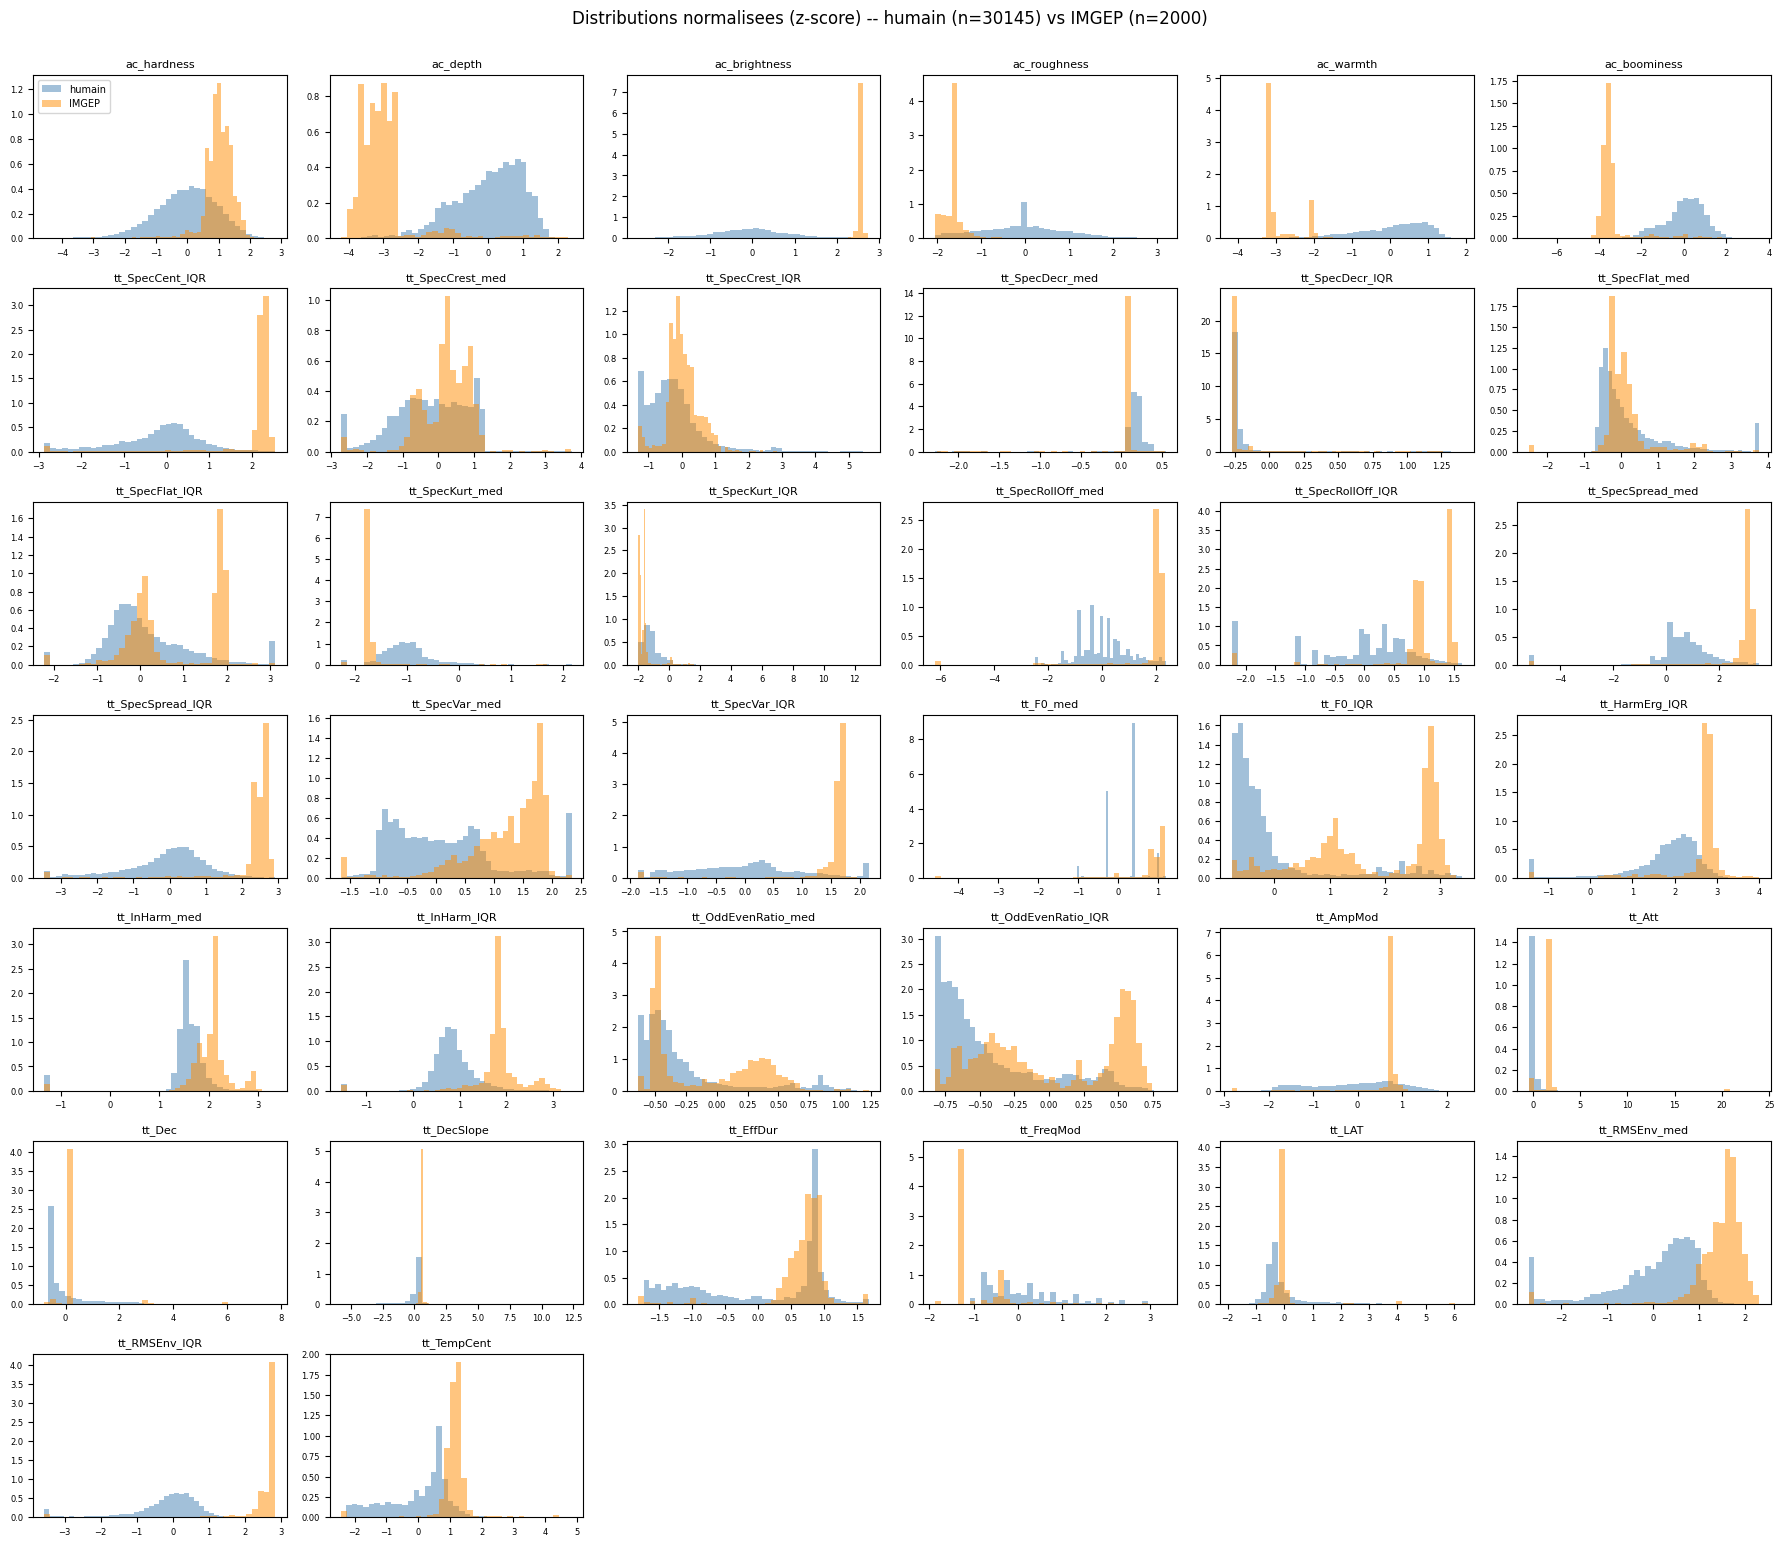

In [6]:
n = len(Z_NAMES)
ncols = 6
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.2 * nrows))
for i, name in enumerate(Z_NAMES):
    ax = axes.flat[i]
    ax.hist(Z_human_norm[:, i], bins=40, density=True, alpha=0.5, label='humain', color='steelblue')
    ax.hist(Z_imgep_norm[:, i], bins=40, density=True, alpha=0.5, label='IMGEP', color='darkorange')
    ax.set_title(name, fontsize=8)
    ax.tick_params(labelsize=6)
for j in range(n, nrows * ncols):
    axes.flat[j].axis('off')
axes.flat[0].legend(fontsize=7)
fig.suptitle(f'Distributions normalisees (z-score) -- humain (n={len(Z_human_norm)}) vs IMGEP (n={len(Z_imgep_norm)})', y=1.001)
plt.tight_layout()
plt.show()

## 7. Projection PCA commune

PCA fittee sur le dataset humain, puis les decouvertes IMGEP sont projetees sur **cette meme
base** (pas re-fittees separement) -- seule facon de superposer les deux nuages de facon
comparable.

Variance expliquee (2 PCs, base humaine): 0.47636936912449307


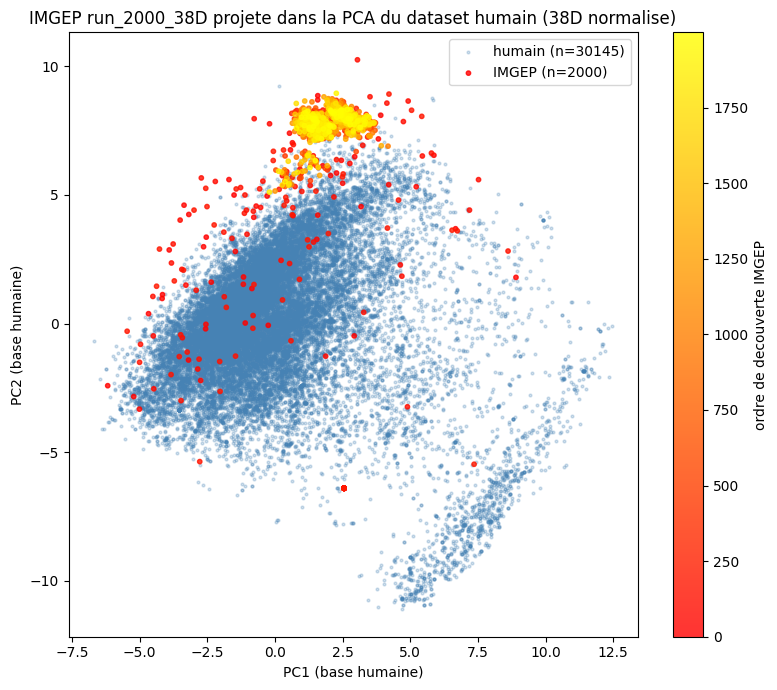

In [7]:
pca = PCA(n_components=2)
human_mean = Z_human_norm.mean(axis=0)
Xh_p = pca.fit_transform(Z_human_norm - human_mean)
Xi_p = pca.transform(Z_imgep_norm - human_mean)
print('Variance expliquee (2 PCs, base humaine):', pca.explained_variance_ratio_[:2].sum())

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(Xh_p[:, 0], Xh_p[:, 1], s=4, alpha=0.25, color='steelblue', label=f'humain (n={len(Xh_p)})')
sc = ax.scatter(Xi_p[:, 0], Xi_p[:, 1], s=10, alpha=0.8, c=order, cmap='autumn', label=f'IMGEP (n={len(Xi_p)})')
ax.set_xlabel('PC1 (base humaine)'); ax.set_ylabel('PC2 (base humaine)')
ax.set_title('IMGEP run_2000_38D projete dans la PCA du dataset humain (38D normalise)')
ax.legend(loc='best')
plt.colorbar(sc, label='ordre de decouverte IMGEP')
plt.tight_layout()
plt.show()

In [8]:
def grid_occupancy(X: np.ndarray, x_edges, y_edges):
    H, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins=[x_edges, y_edges])
    return (H > 0).sum() / H.size

## 7bis. Projection UMAP commune

Meme principe que la PCA ci-dessus, mais avec UMAP (qui capture mieux les structures non
lineaires, cf. `dexed_audit_TT_ACTM_ttb.ipynb`) : `reducer.fit()` sur le dataset humain
uniquement, puis `reducer.transform()` des decouvertes IMGEP dans **cet embedding deja
appris** -- essentiel pour que les deux nuages soient comparables (un UMAP re-fitte sur
l'union des deux, ou separement sur chacun, donnerait des coordonnees non comparables).

/data/anasynth_nonbp/longeot/envs/spinvae_2_18_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


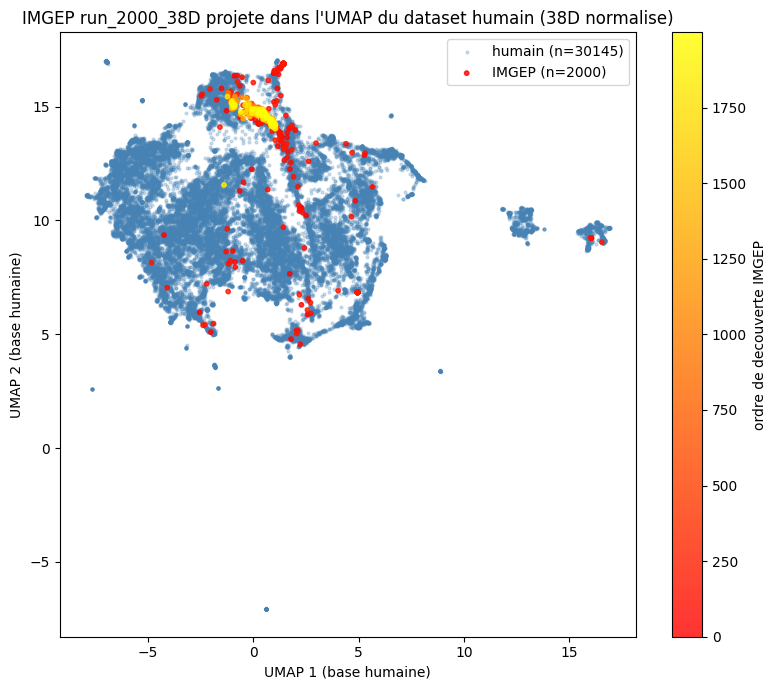

In [9]:
import sys as _sys
_sys.modules['umap.parametric_umap'] = None  # empeche un import qui plante (cf. dexed_audit_TT_ACTM_ttb.ipynb)
import umap

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0)
Xh_u = reducer.fit_transform(Z_human_norm)
Xi_u = reducer.transform(Z_imgep_norm)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(Xh_u[:, 0], Xh_u[:, 1], s=4, alpha=0.25, color='steelblue', label=f'humain (n={len(Xh_u)})')
sc = ax.scatter(Xi_u[:, 0], Xi_u[:, 1], s=10, alpha=0.8, c=order, cmap='autumn', label=f'IMGEP (n={len(Xi_u)})')
ax.set_xlabel('UMAP 1 (base humaine)'); ax.set_ylabel('UMAP 2 (base humaine)')
ax.set_title('IMGEP run_2000_38D projete dans l\'UMAP du dataset humain (38D normalise)')
ax.legend(loc='best')
plt.colorbar(sc, label='ordre de decouverte IMGEP')
plt.tight_layout()
plt.show()

### 7bis.1 Occupation de grille sur l'embedding UMAP

Meme calcul que la section 8.1 (grille commune, bornes fixees par l'union des deux nuages),
mais sur UMAP plutot que PCA -- UMAP etant non lineaire, la structure/les clusters y sont
generalement plus lisibles que sur la PCA (moins de variance totale expliquee, cf. audit
sections 2 et 5).

In [10]:
n_bins = 50
all_xu = np.concatenate([Xh_u[:, 0], Xi_u[:, 0]])
all_yu = np.concatenate([Xh_u[:, 1], Xi_u[:, 1]])
xu_edges = np.linspace(all_xu.min(), all_xu.max(), n_bins + 1)
yu_edges = np.linspace(all_yu.min(), all_yu.max(), n_bins + 1)

occ_human_u = grid_occupancy(Xh_u, xu_edges, yu_edges)
occ_imgep_u = grid_occupancy(Xi_u, xu_edges, yu_edges)
print(f'Occupation grille {n_bins}x{n_bins} (base UMAP humaine) :')
print(f'  humain (n={len(Xh_u)}): {occ_human_u:.1%}')
print(f'  IMGEP  (n={len(Xi_u)}): {occ_imgep_u:.1%}')

Occupation grille 50x50 (base UMAP humaine) :
  humain (n=30145): 22.2%
  IMGEP  (n=2000): 3.4%


## 8. Metriques de couverture (natif 38D, normalise) -- comparables terme a terme

Meme methodologie que le rapport d'audit (section 2) : distance moyenne au plus proche voisin
en 38D natif, comparee a un nuage uniforme aleatoire de meme taille et meme boite englobante
(un ratio proche de 1 = aussi etale qu'un tirage uniforme ; proche de 0 = tres concentre/clustered).

In [11]:
def nn_ratio_vs_uniform(Z: np.ndarray, k: int = 1, n_uniform_repeats: int = 5, seed: int = 0):
    tree = Z_dists = None
    tree = cKDTree(Z)
    d, _ = tree.query(Z, k=k + 1)
    mean_nn = float(d[:, k].mean())

    rng = np.random.default_rng(seed)
    lo, hi = Z.min(axis=0), Z.max(axis=0)
    ratios = []
    for _ in range(n_uniform_repeats):
        U = rng.uniform(lo, hi, size=Z.shape)
        ut = cKDTree(U)
        du, _ = ut.query(U, k=k + 1)
        ratios.append(mean_nn / du[:, k].mean())
    return mean_nn, float(np.mean(ratios))

print('--- Dataset humain (38D normalise, n=%d) ---' % len(Z_human_norm))
for k in (1, 5):
    mnn, ratio = nn_ratio_vs_uniform(Z_human_norm, k=k)
    print(f'  k={k}: mean NN dist = {mnn:.3f}, ratio vs uniforme = {ratio:.3f}')

print('\n--- IMGEP run_2000_38D (38D normalise, n=%d) ---' % len(Z_imgep_norm))
for k in (1, 5):
    mnn, ratio = nn_ratio_vs_uniform(Z_imgep_norm, k=k)
    print(f'  k={k}: mean NN dist = {mnn:.3f}, ratio vs uniforme = {ratio:.3f}')

--- Dataset humain (38D normalise, n=30145) ---


  k=1: mean NN dist = 0.955, ratio vs uniforme = 0.107


  k=5: mean NN dist = 1.858, ratio vs uniforme = 0.191

--- IMGEP run_2000_38D (38D normalise, n=2000) ---


  k=1: mean NN dist = 0.922, ratio vs uniforme = 0.099


  k=5: mean NN dist = 1.223, ratio vs uniforme = 0.120


### 8.1 Occupation de grille (base PCA commune)

Meme grille (bornes fixees par l'union des deux nuages) pour que les pourcentages soient
directement comparables.

In [12]:
n_bins = 50
all_x = np.concatenate([Xh_p[:, 0], Xi_p[:, 0]])
all_y = np.concatenate([Xh_p[:, 1], Xi_p[:, 1]])
x_edges = np.linspace(all_x.min(), all_x.max(), n_bins + 1)
y_edges = np.linspace(all_y.min(), all_y.max(), n_bins + 1)

occ_human = grid_occupancy(Xh_p, x_edges, y_edges)
occ_imgep = grid_occupancy(Xi_p, x_edges, y_edges)
print(f'Occupation grille {n_bins}x{n_bins} (base PCA humaine) :')
print(f'  humain (n={len(Xh_p)}): {occ_human:.1%}')
print(f'  IMGEP  (n={len(Xi_p)}): {occ_imgep:.1%}')
print('\n(rappel: IMGEP n=2000 << humain n=30145, donc une occupation plus faible est attendue')
print(' meme si IMGEP explore aussi bien proportionnellement -- comparer plutot au ratio NN/uniforme ci-dessus,')
print(' qui normalise par la taille du nuage.)')

Occupation grille 50x50 (base PCA humaine) :
  humain (n=30145): 47.8%
  IMGEP  (n=2000): 7.4%

(rappel: IMGEP n=2000 << humain n=30145, donc une occupation plus faible est attendue
 meme si IMGEP explore aussi bien proportionnellement -- comparer plutot au ratio NN/uniforme ci-dessus,
 qui normalise par la taille du nuage.)


## 9. Conclusion

A completer une fois les cellules ci-dessus executees -- points a discuter :
- Les distributions par feature (section 6) se recouvrent-elles globalement, ou IMGEP a-t-il
  trouve des zones (F0 tres bas/haut, inharmonicite extreme...) absentes du dataset humain ?
  C'est le comportement attendu de la curiosite (IMGEP vise l'inexplore), a distinguer d'un bug.
- Le ratio distance-NN/uniforme d'IMGEP (section 8) est-il plus proche de 1 (exploration plus
  uniforme que les presets humains, cf. hypothese de section 1 de l'internship) ou lui aussi
  < 1 (comportement acoustique intrinsequement clustered, independant de la methode d'exploration) ?
- Prochaine etape naturelle si le volume est jugee insuffisant : relancer un `run_XXXX_38D` plus
  long, ou lancer plusieurs seeds en parallele pour des barres d'erreur sur ces ratios.